# 手动指定牧原生长曲线

In [1]:
import numpy as np
import pandas as pd

def target_feed_curve(x, b0, b1, b2, b3, smearing=1.0):

    log_x = np.log(x + 1e-6)

    res = smearing * np.expm1(b0+b1*log_x+b2*log_x**2+b3*log_x**3)
    return res

经过搜寻的最优拟合曲线参数如下：

In [ ]:
b0 = -17.221380825868643   
b1 = 11.829439580591034
b2 = -2.667389061994757
b3 = 0.2052711462790713
smearing = 1.0

# 计算目标值
TARGET_WEANING_WEIGHT = 7.0
# 日龄
target_df_my = pd.DataFrame({
    'age': np.arange(21, 150, 1),
})
# 日增长
target_df_my['target_day_weight'] = target_feed_curve(target_df_my['age'].values, b0, b1, b2, b3)
# 体重
target_df_my['target_weight'] = target_df_my['target_day_weight'].cumsum() + TARGET_WEANING_WEIGHT

# 保存
from feed_analysis.config.path import PATH_GROWTH
target_df_my.to_excel(PATH_GROWTH/'牧原-日龄-日增重-log-poly3拟合.xlsx', index=False)

# 牧原三点目标值数据（数据来源：牧原交流-指标展示）
my_3point_df = pd.DataFrame({'age': [21, 70, 145],'weight': [7, 33.95, 120],})

In [ ]:
# 总体重-日龄曲线
import plotly.graph_objects as go
fig = go.Figure()

fig.add_trace(go.Scatter(x=target_df_my['age'], y=target_df_my['target_weight'], mode='lines', name='牧原期望生长曲线'))
fig.add_trace(go.Scatter(x=my_3point_df['age'], y=my_3point_df['weight'], mode='markers', name='牧原节点目标值'))
fig.update_layout(title='牧原生长期望曲线拟合 x-日龄 y-重量')

In [ ]:
# 日增重-日龄曲线
import plotly.graph_objects as go
target_df_my = target_df_my[target_df_my['target_day_weight']>0]
fig = go.Figure()
fig.add_trace(go.Scatter(x=target_df_my['age'], y=target_df_my['target_day_weight'], mode='lines+markers', name='牧原期望日增重曲线'))
fig.update_layout(title='牧原生长期望曲线拟合 x-日龄 y-日增重')

## 搜索最优参数

In [ ]:
# # 目标点
# ages = np.array([21, 70, 145])
# targets = np.array([7.0, 33.95, 120.0])
# TARGET_WEANING_WEIGHT = 7.0
# target_df = pd.DataFrame({
#     'age': np.arange(21, 150, 1),
# })

# # 搜索中心
# b0_0 = -17.021380825868643
# b1_0 = 11.78470273848577
# b2_0 = -2.6331785356789674
# b3_0 = 0.19737640943696605
# smearing = 1.0

# # 搜索范围（非常关键）
# grid = {
#     "b0": np.linspace(b0_0 - 0.2, b0_0 + 0.2, 20),
#     "b1": np.linspace(b1_0 - 0.05, b1_0 + 0.05, 20),
#     "b2": np.linspace(b2_0 - 0.05, b2_0 + 0.05, 20),
#     "b3": np.linspace(b3_0 - 0.05, b3_0 + 0.05, 20),
# }

# from tqdm import tqdm

# for b0 in tqdm(grid["b0"], desc="Searching b0"):
#     for b1 in grid["b1"]:
#         for b2 in grid["b2"]:
#             for b3 in grid["b3"]:

#                 x = target_df['age'].values
#                 pred_day_weight = target_feed_curve(x, b0, b1, b2, b3)  # 日增重预测值

#                 target_df['pred_day_weight'] = pred_day_weight
#                 target_df['pred_weight'] = target_df['pred_day_weight'].cumsum() + TARGET_WEANING_WEIGHT
#                 # print(target_df)

#                 # if pred_day_weight[0] < 0.0:
#                 #     # print('predict less than 0, skip')
#                 #     continue

#                 key_1 = target_df.loc[target_df['age']==21, 'pred_weight'].values[0]
#                 key_2 = target_df.loc[target_df['age']==70, 'pred_weight'].values[0]
#                 # print( target_df)
#                 key_3 = target_df.loc[target_df['age']==145, 'pred_weight'].values[0]

#                 if abs(key_1 - targets[0]) < 0.5 and abs(key_2 - targets[1]) < 0.5 and abs(key_3 - targets[2]) < 0.5:
#                     err = np.sqrt((key_1 - targets[0])**2 + (key_2 - targets[1])**2 + (key_3 - targets[2])**2)
#                     print("✅ Found solution:", b0, b1, b2, b3, "err=", err)
#                     break


缺点：在最开始的部分没办法进行更精细的拟合，会出现日增长为负数

待选参数清单：

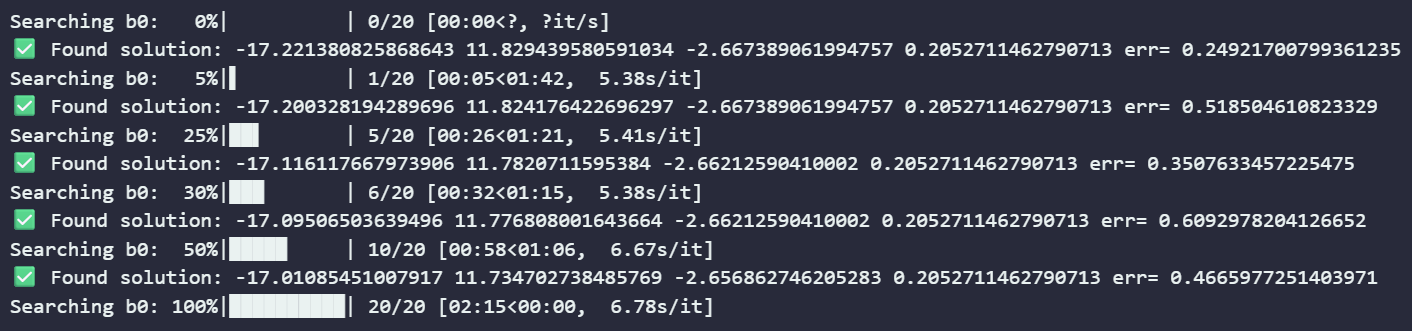


Searching b0:  36%|███▌      | 18/50 [00:55<01:27,  2.73s/it]✅ Found solution: -17.274442050358438 11.769600697669445 -2.632362209148355 0.20104987882472117 err= 0.08467083596021041
✅ Found solution: -17.274442050358438 11.77613130991434 -2.635627515270804 0.20145804209002727 err= 0.08252102798816452
Searching b0:  38%|███▊      | 19/50 [00:58<01:25,  2.77s/it]✅ Found solution: -17.266278785052315 11.772457840526586 -2.635219352005498 0.20145804209002727 err= 0.07791119490262588
✅ Found solution: -17.266278785052315 11.780621105832708 -2.638892821393253 0.2018662053553334 err= 0.0480465701378705
Searching b0:  40%|████      | 20/50 [01:01<01:28,  2.96s/it]✅ Found solution: -17.258115519746195 11.768784371138832 -2.634811188740192 0.20145804209002727 err= 0.07330506709236317
✅ Found solution: -17.258115519746195 11.776947636444953 -2.638484658127947 0.2018662053553334 err= 0.04393603653151956
✅ Found solution: -17.258115519746195 11.78143743236332 -2.6413418009850895 0.20227436862063952 err= 0.09612957897410013
Searching b0:  42%|████▏     | 21/50 [01:05<01:28,  3.04s/it]✅ Found solution: -17.24995225444007 11.765110901751076 -2.6344030254748856 0.20145804209002727 err= 0.06870264551483274
✅ Found solution: -17.24995225444007 11.773274167057199 -2.638076494862641 0.2018662053553334 err= 0.0399591723961521
✅ Found solution: -17.24995225444007 11.777763962975566 -2.6409336377197836 0.20227436862063952 err= 0.08908934993102946
✅ Found solution: -17.24995225444007 11.78143743236332 -2.641749964250396 0.20227436862063952 err= 0.05584467328537812
Searching b0:  44%|████▍     | 22/50 [01:08<01:26,  3.08s/it]✅ Found solution: -17.241788989133948 11.769600697669445 -2.6376683315973346 0.2018662053553334 err= 0.03770897402982598
✅ Found solution: -17.241788989133948 11.774090493587812 -2.6405254744544773 0.20227436862063952 err= 0.08182923898280592
✅ Found solution: -17.241788989133948 11.777763962975566 -2.6413418009850895 0.20227436862063952 err= 0.06352303837153528
Searching b0:  46%|████▌     | 23/50 [01:10<01:17,  2.88s/it]✅ Found solution: -17.241788989133948 11.782253758893933 -2.6441989438422326 0.20268253188594565 err= 0.05606156834980425
✅ Found solution: -17.233625723827828 11.765927228281688 -2.6372601683320287 0.2018662053553334 err= 0.045379856561893916
✅ Found solution: -17.233625723827828 11.770417024200055 -2.6401173111891714 0.20227436862063952 err= 0.0741719787748849
✅ Found solution: -17.233625723827828 11.774090493587812 -2.6409336377197836 0.20227436862063952 err= 0.0712045221165738
✅ Found solution: -17.233625723827828 11.778580289506179 -2.6437907805769263 0.20268253188594565 err= 0.05531532054214949
Searching b0:  48%|████▊     | 24/50 [01:13<01:11,  2.75s/it]✅ Found solution: -17.233625723827828 11.782253758893933 -2.6446071071075385 0.20268253188594565 err= 0.09706540234640215
✅ Found solution: -17.225462458521704 11.766743554812301 -2.639709147923865 0.20227436862063952 err= 0.06651160803212974
✅ Found solution: -17.225462458521704 11.770417024200055 -2.6405254744544773 0.20227436862063952 err= 0.0788891257948805
✅ Found solution: -17.225462458521704 11.774906820118423 -2.6433826173116204 0.20268253188594565 err= 0.059279176541991774
Searching b0:  50%|█████     | 25/50 [01:15<01:06,  2.65s/it]✅ Found solution: -17.225462458521704 11.783070085424546 -2.6470560866993753 0.20309069515125178 err= 0.08706629408446531
✅ Found solution: -17.21729919321558 11.766743554812301 -2.6401173111891714 0.20227436862063952 err= 0.0865768506799327
✅ Found solution: -17.21729919321558 11.771233350730668 -2.642974454046314 0.20268253188594565 err= 0.06323894611952596
✅ Found solution: -17.21729919321558 11.77939661603679 -2.646647923434069 0.20309069515125178 err= 0.09101102007538486
Searching b0:  52%|█████▏    | 26/50 [01:18<01:03,  2.64s/it]✅ Found solution: -17.209135927909458 11.767559881342914 -2.642566290781008 0.20268253188594565 err= 0.06719462809462584
✅ Found solution: -17.209135927909458 11.775723146649035 -2.646239760168763 0.20309069515125178 err= 0.09495165462240607
✅ Found solution: -17.209135927909458 11.782253758893933 -2.649505066291212 0.2034988584165579 err= 0.07330626529336826
Searching b0:  54%|█████▍    | 27/50 [01:21<01:04,  2.81s/it]✅ Found solution: -17.200972662603338 11.763886411955157 -2.642158127515702 0.20268253188594565 err= 0.07114622127905079
✅ Found solution: -17.200972662603338 11.770417024200055 -2.645423433638151 0.20309069515125178 err= 0.0971365424179993
✅ Found solution: -17.200972662603338 11.77204967726128 -2.6458315969034567 0.20309069515125178 err= 0.09888819653555458
✅ Found solution: -17.200972662603338 11.778580289506179 -2.6490969030259057 0.2034988584165579 err= 0.06936443151660399
Searching b0:  56%|█████▌    | 28/50 [01:24<01:04,  2.93s/it]✅ Found solution: -17.192809397297214 11.766743554812301 -2.645015270372845 0.20309069515125178 err= 0.09318374101849258
✅ Found solution: -17.192809397297214 11.774906820118423 -2.6486887397606 0.2034988584165579 err= 0.06542669391028255
✅ Found solution: -17.192809397297214 11.77939661603679 -2.6515458826177425 0.203907021681864 err= 0.09238734695686901
Searching b0:  58%|█████▊    | 29/50 [01:27<01:03,  3.04s/it]✅ Found solution: -17.192809397297214 11.783070085424546 -2.6523622091483547 0.203907021681864 err= 0.05306460439859961
✅ Found solution: -17.18464613199109 11.771233350730668 -2.6482805764952935 0.2034988584165579 err= 0.06149305367243585
✅ Found solution: -17.18464613199109 11.775723146649035 -2.6511377193524366 0.203907021681864 err= 0.08470008163129705
✅ Found solution: -17.18464613199109 11.77939661603679 -2.651954045883049 0.203907021681864 err= 0.06077618328944823
Searching b0:  60%|██████    | 30/50 [01:31<01:01,  3.08s/it]✅ Found solution: -17.17648286668497 11.767559881342914 -2.6478724132299876 0.2034988584165579 err= 0.057563511988135474
✅ Found solution: -17.17648286668497 11.77204967726128 -2.6507295560871302 0.203907021681864 err= 0.0770096931696429
✅ Found solution: -17.17648286668497 11.775723146649035 -2.6515458826177425 0.203907021681864 err= 0.06849089475726089
Searching b0:  62%|██████▏   | 31/50 [01:34<00:58,  3.10s/it]✅ Found solution: -17.168319601378847 11.763886411955157 -2.647464249964681 0.2034988584165579 err= 0.05363807005242904
✅ Found solution: -17.168319601378847 11.768376207873525 -2.6503213928218243 0.203907021681864 err= 0.06931618029696551
✅ Found solution: -17.168319601378847 11.77204967726128 -2.6511377193524366 0.203907021681864 err= 0.07620874008109979
Searching b0:  64%|██████▍   | 32/50 [01:37<00:56,  3.11s/it]✅ Found solution: -17.160156336072724 11.76470273848577 -2.649913229556518 0.203907021681864 err= 0.06161954173475692
✅ Found solution: -17.160156336072724 11.768376207873525 -2.6507295560871302 0.203907021681864 err= 0.0839297205418319
Searching b0:  66%|██████▌   | 33/50 [01:40<00:53,  3.15s/it]✅ Found solution: -17.1519930707666 11.76470273848577 -2.6503213928218243 0.203907021681864 err= 0.09165383742077893
Searching b0: 100%|██████████| 50/50 [02:34<00:00,  3.10s/it]